<a href="https://colab.research.google.com/github/etebongibekwe-stack/Beam-shaping/blob/main/Etebong_Ibekwe_NN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Etebong_Ibekwe**


**Abstract**: We import necessary libraries, generate temperatures Te, Ti and Tw. Then use the data to train a model that learn the temperatures pattern and then fit the temperatur curves with the model's predictions. Section 2, the same process is done but by adding the PINN then fit the curves with the PINN prediction. Section 3, we create simulator function call tep, that take tau and fluence and return the temperatures Te, Ti, and Tw. We generate data from tep for 30 different values of tau and fluence, then create a model that take the data and predict tau and fluence value.

Absorption cross-section: 7.786474865982591e-18


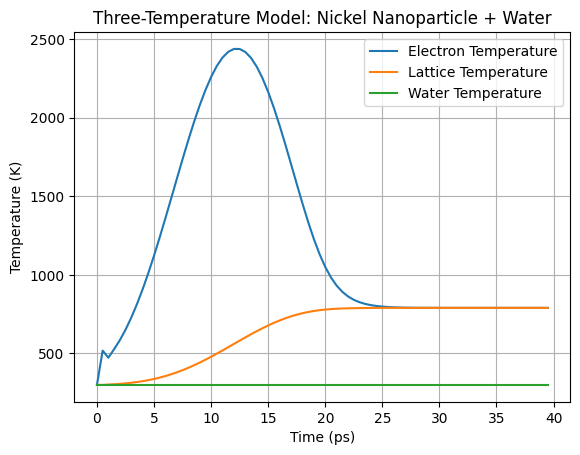

In [1]:

import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Constants (SI units)

K_B = 1.380649e-23  # Boltzmann constant, J/K

C_e_coeff = 100  # Rough estimation for the electronic heat capacity coefficient,
# J/(m^3*K^2) Ce(Te) ? Pas une fonciton de la tempréature ?

C_i = 4.5e6  # Lattice heat capacity, J/(m^3*K)

C_w = 4.184e6  # Heat capacity of water, J/(m^3*K)

gamma = 1e17  # Electron-phonon coupling constant, W/(m^3*K) G(Te) ?

h = 1e5  # Heat transfer coefficient to water, W/(m^2*K)

T_m = 300  # Initial water temperature, K (also initial NP temp)

radius = 5e-9  # Nanoparticle radius, m

area = np.pi * (radius**2)  # Cross-sectional area, m^2

volume = (4/3) * np.pi * (radius**3)  # Nanoparticle volume, m^3

water_volume = (4/3) * np.pi * ((radius * 2)**3) - volume

# Define size of water volume around NanoParticle for modelling heat dissipation.

# Laser parameters

fluence = 300  # J/m^2 (30 mJ/cm^2)

tau = 1e-11  # Pulse duration, s (100 fs)

wavelength = 400e-9  # Laser wavelength, m

# Optical Properties (Nickel) - Change for other materials as needed

n = 2.3  # Refractive index

k = 3.5  # Extinction coefficient

epsilon = (n + 1j * k)**2  # Complex dielectric function

epsilon_m = 1.77  # Water dielectric function

sigma_abs = ((8 * np.pi**2 * radius**3) / wavelength) * np.imag((epsilon - epsilon_m) / (epsilon + 2 * epsilon_m))

print("Absorption cross-section:", sigma_abs)

# Time axis setup

time_step = tau / 20  # Smaller time steps for more accurate results

time = np.arange(0, 40e-12, time_step)  # Time from 0 to 40 ps

# Gaussian laser pulse function (Corrected for peak at t=0)

def gaussian_pulse(t):

    return (fluence / (tau * np.sqrt(np.pi / np.log(2)))) * np.exp((-4 * np.log(2) * (t - tau)**2) / tau**2) # Fixed time component

# Time-dependent laser source term Q (Power density)

intensity = gaussian_pulse(time)

Q = (sigma_abs * intensity) / volume  # Volumetric heat source, W/m^3

# Initialize temperature arrays

Te = np.zeros(len(time))

Ti = np.zeros(len(time))

Tw = np.zeros(len(time))

Te[0] = T_m  # Initial temperatures equal to surrounding water

Ti[0] = T_m

Tw[0] = T_m

#Verlet Algorithm (Explicit):

for i in range(0, len(time) - 1):

    C_e = C_e_coeff * Te[i]  # Update electron heat capacity based on temperature

    dt = time_step

    # Calculate new Te, Ti and Tw

    Te[i + 1] = Te[i] + (dt / C_e) * (-gamma * (Te[i] - Ti[i]) + Q[i] - h * (Te[i] - Tw[i]))

    Ti[i + 1] = Ti[i] + (dt / C_i) * (gamma * (Te[i] - Ti[i]) - h * (Ti[i] - Tw[i]))

    Tw[i + 1] = Tw[i] + (dt / C_w) * (h * (Ti[i] - Tw[i]) * volume / water_volume)

    # Ensure temperatures don't go below 0

    Te[i + 1] = max(Te[i + 1], 0)

    Ti[i + 1] = max(Ti[i + 1], 0)

    Tw[i + 1] = max(Tw[i + 1], 0)



# Plotting the results

plt.plot(time / (1e-12), Te, label="Electron Temperature")

plt.plot(time / (1e-12), Ti, label="Lattice Temperature")

plt.plot(time / (1e-12), Tw, label="Water Temperature")

plt.xlabel("Time (ps)")

plt.ylabel("Temperature (K)")

plt.title("Three-Temperature Model: Nickel Nanoparticle + Water")

plt.legend()

plt.grid(True)

plt.show()



**Task One:**  Fit the curve (i.e. a model that intput time and output the three temperatures. Don't forget to use train/test/val split). You can do it for different laser parameters

Remarks for task One: The aim was to train a neural network that takes time t as input and predicts the three temperatures [Ti(t), Te(t), Tw(t)] produced by the physical simulator.

We use part of the data for training and keep part for testing, so we can check if the model generalizes to unseen time points.

In [2]:
#Data preparation
X=time = time.reshape(-1, 1)  # we reshape time to (N,1) so it can go into a linear layer
Y=np.vstack([Ti, Te, Tw]).T  # we stack Ti, Te, Tw into one (N,3) target matrix

In [3]:
#Normalized Data
X = (X - X.min()) / (X.max() - X.min())  # normalize time to [0,1] so the scale is well-behaved
Y_mean = Y.mean(axis=0)                  # It computes the mean of each channel (Ti, Te, Tw)
Y_std = Y.std(axis=0)                    # It computes the std of each channel (Ti, Te, Tw)
Y_norm = (Y - Y_mean) / Y_std            # Outputs were standardized so each target has mean 0 and std 1

In [4]:
# 3. Train/test split
# we keep 20% of the data as a held-out test set to check generalization
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_norm, test_size=0.2, random_state=42)

In [5]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32) # It converts training inputs to torch tensors
Y_train = torch.tensor(Y_train, dtype=torch.float32) # converts training targets to torch tensors
X_test  = torch.tensor(X_test, dtype=torch.float32)  # converts test inputs to torch tensors
Y_test  = torch.tensor(Y_test, dtype=torch.float32)  # converts test targets to torch tensors

In [6]:
# 4. Define neural network model
# -------------------------------------------------
class TempPredictor(nn.Module):     # we define an MLP that maps time → [Ti, Te, Tw]
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),       # we take 1 input feature (time)
            nn.ReLU(),              # we apply ReLU nonlinearity
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)  # 3D output
        )

    def forward(self, x):
        return self.net(x)

model = TempPredictor()


In [7]:
# 5. Train the model
# Print both training loss and test loss during training to monitor performance.
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(3000):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, Y_train)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        model.eval()
        test_pred = model(X_test)
        test_loss = criterion(test_pred, Y_test)
        print(f"Epoch {epoch:4d} | Train Loss: {loss.item():.6f} | Test Loss: {test_loss.item():.6f}")


Epoch    0 | Train Loss: 1.011051 | Test Loss: 1.102223
Epoch  500 | Train Loss: 0.001603 | Test Loss: 0.004230
Epoch 1000 | Train Loss: 0.000253 | Test Loss: 0.000689
Epoch 1500 | Train Loss: 0.000173 | Test Loss: 0.000554
Epoch 2000 | Train Loss: 0.000140 | Test Loss: 0.000583
Epoch 2500 | Train Loss: 0.000111 | Test Loss: 0.000636


In [8]:
# 6. Predict and unnormalize
# These generates final predictions with the trained model
model.eval()
with torch.no_grad():
    Y_pred_norm = model(torch.tensor(X, dtype=torch.float32)).numpy()
    Y_pred = Y_pred_norm * Y_std + Y_mean  # reverse normalization

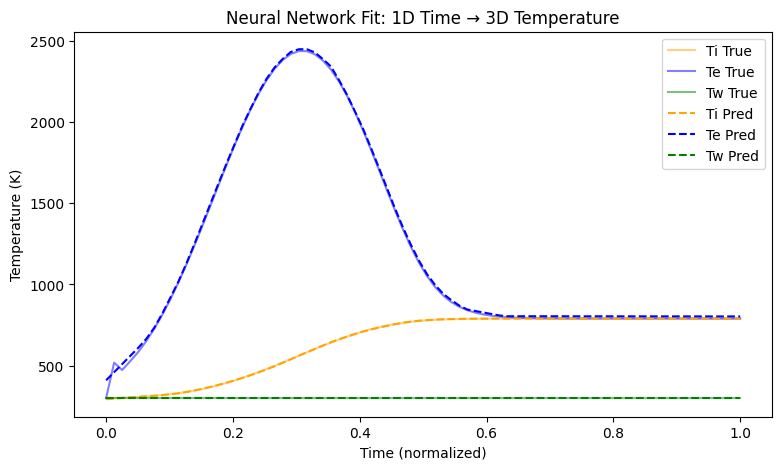

In [9]:
# 7. Plot results
# -------------------------------------------------
plt.figure(figsize=(9,5))
plt.plot(X, Y[:,0], label="Ti True", color="orange", alpha=0.5)
plt.plot(X, Y[:,1], label="Te True", color="blue", alpha=0.5)
plt.plot(X, Y[:,2], label="Tw True", color="green", alpha=0.5)

plt.plot(X, Y_pred[:,0], "--", color="orange", label="Ti Pred")
plt.plot(X, Y_pred[:,1], "--", color="blue", label="Te Pred")
plt.plot(X, Y_pred[:,2], "--", color="green", label="Tw Pred")

plt.xlabel("Time (normalized)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.title("Neural Network Fit: 1D Time → 3D Temperature")
plt.show()

**Task 2 PINN:**  Fit the curve with a PINN.


TASK 2 — Physics Informed Neural Network (PINN)
The goal was to  learn Te, Ti, Tw as functions of time, but with physics built into the loss:
 data loss (fit the simulated temperatures)
 physics loss (enforce the ODEs of the 3 temperature model)
 initial condition loss (match starting temperature)

Epoch 0/4999 | Total: 3.994e+05 | Data: 6.335e-01 | Phys: (3.992e+29,1.007e+26,5.165e-01)
Epoch 250/4999 | Total: 2.559e+04 | Data: 2.954e+01 | Phys: (2.264e+28,3.776e+26,3.483e+01)
Epoch 500/4999 | Total: 1.559e+04 | Data: 5.798e+01 | Phys: (1.058e+28,4.572e+26,6.756e+01)
Epoch 750/4999 | Total: 1.176e+04 | Data: 6.563e+01 | Phys: (6.812e+27,2.532e+26,7.904e+01)
Epoch 1000/4999 | Total: 3.275e+03 | Data: 5.039e+01 | Phys: (2.204e+26,8.872e+25,1.146e+02)
Epoch 1250/4999 | Total: 1.425e+03 | Data: 2.982e+01 | Phys: (4.181e+25,2.839e+26,1.216e+02)
Epoch 1500/4999 | Total: 7.402e+02 | Data: 1.560e+01 | Phys: (1.649e+25,1.605e+26,6.805e+01)
Epoch 1750/4999 | Total: 3.161e+02 | Data: 6.480e+00 | Phys: (9.999e+24,5.166e+25,3.288e+01)
Epoch 2000/4999 | Total: 1.078e+02 | Data: 2.053e+00 | Phys: (7.102e+24,1.433e+25,1.512e+01)
Epoch 2250/4999 | Total: 3.990e+01 | Data: 6.643e-01 | Phys: (4.799e+24,6.176e+24,8.843e+00)
Epoch 2500/4999 | Total: 2.144e+01 | Data: 2.481e-01 | Phys: (6.337e+24,2.33

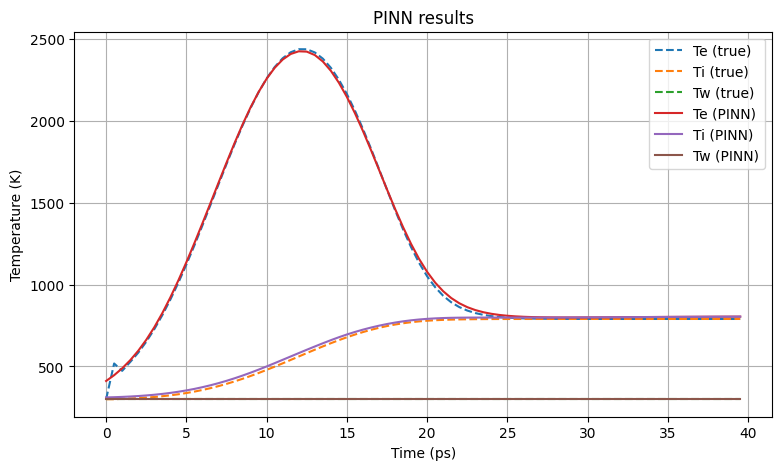

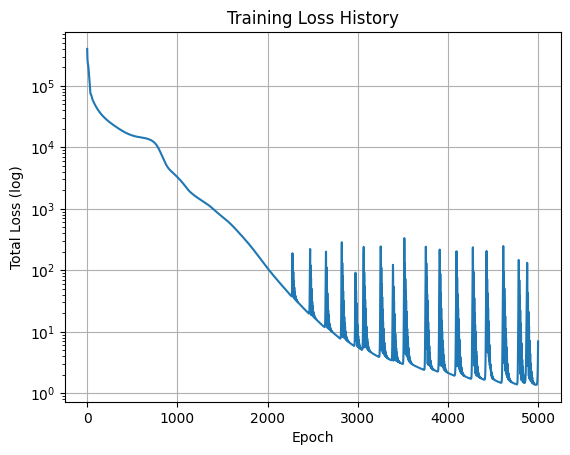

In [10]:
# Complete PINN using your grad() and physics residuals idea
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# BLOCK A — Prepare simulation data for the PINN
# Assumes the forward model has already produced:time  (s), Te, Ti, Tw (K), Q (W/m^3), and constants (gamma, C_e_coeff, etc.).
# Converts arrays to float64 for stable autograd and reshapes them.

time = np.asarray(time, dtype=np.float64).reshape(-1)   # original physical time (s)
Te = np.asarray(Te, dtype=np.float64).reshape(-1)
Ti = np.asarray(Ti, dtype=np.float64).reshape(-1)
Tw = np.asarray(Tw, dtype=np.float64).reshape(-1)
Q = np.asarray(Q, dtype=np.float64).reshape(-1)

# BLOCK B — Normalize inputs/outputs-Normalizes time to [0,1] for the network input. Standardizes Te, Ti, Tw (per channel) to mean 0 and std 1 for stable training.
# Also creates train/test splits for data-fitting.

# Input normalization: map time -> t_hat in [0,1]
t_min, t_max = float(np.min(time)), float(np.max(time))
t_hat = (time - t_min) / (t_max - t_min)                # numpy normalized time in [0,1]
X = t_hat.reshape(-1, 1)

# Output normalization: standardize (mean/std) per channel
Y = np.vstack([Te, Ti, Tw]).T                          # shape (N,3)
Y_mean = np.mean(Y, axis=0)                            # mean for each variable
Y_std = np.std(Y, axis=0) + 1e-9                       # std (avoid zero)

Y_norm = (Y - Y_mean) / Y_std                          # normalized outputs

# Train/test split using sklearn
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_norm, test_size=0.2, random_state=42, shuffle=True)

# Convert to torch tensors (double precision)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_t = torch.tensor(X_train, dtype=torch.float64, requires_grad=True, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float64, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float64, requires_grad=True, device=device)
Y_test_t = torch.tensor(Y_test, dtype=torch.float64, device=device)

# Full grid tensors for plotting/evaluation
X_full_t = torch.tensor(X, dtype=torch.float64, requires_grad=True, device=device)
Y_full = Y  # numpy original (un-normalized)
Y_full_norm = Y_norm


# BLOCK C — Gradient helper: Small utility to compute d(output)/d(input) with graph tracking. This is how we get time derivatives of Te, Ti, Tw from the network.
def grad(outputs, inputs):
    """Computes partial derivative d(outputs)/d(inputs) with create_graph=True"""
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs, device=device),
        create_graph=True,
        retain_graph=True
    )

# BLOCK D — Define the PINN model
# A neural network that takes normalized time t_hat and predicts. Te, Ti, Tw (still in normalized units).
# We use Tanh activations, which are common in PINNs because they’re smooth.
class PINN(nn.Module):
    def __init__(self, hidden_units=64):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_units),
            nn.Tanh(),
            nn.Linear(hidden_units, hidden_units),
            nn.Tanh(),
            nn.Linear(hidden_units, hidden_units),
            nn.Tanh(),
            nn.Linear(hidden_units, 3)   # outputs: normalized Te, Ti, Tw
        )
    def forward(self, x):
        return self.net(x)

model = PINN(hidden_units=64).to(device).double()

# BLOCK E — Pack physical constants into torch tensors; These are the parameters of the 3-temperature model ODEs.
# They go into the physics loss so the network is forced to obey the equations.

G = torch.tensor(float(gamma), dtype=torch.float64, device=device)
C_e_coeff_t = torch.tensor(float(C_e_coeff), dtype=torch.float64, device=device)
C_i_t = torch.tensor(float(C_i), dtype=torch.float64, device=device)
C_w_t = torch.tensor(float(C_w), dtype=torch.float64, device=device)
h_t = torch.tensor(float(h), dtype=torch.float64, device=device)
volume_t = torch.tensor(float(volume), dtype=torch.float64, device=device)
water_volume_t = torch.tensor(float(water_volume), dtype=torch.float64, device=device)

# We'll also need Q(t) (laser heating term) at arbitrary times,so we keep the original arrays to interpolate during training.
time_np = time.copy()
Q_np = Q.copy()

# BLOCK F — Physics loss
# This block enforces the actual differential equations. The network predicts Te, Ti, Tw. We take time derivatives using autograd. We compute the right-hand side of the 3-temperature model ODEs.
#This is what makes it a PINN
def physics_loss(model, t_coll_tensor):
    """
    Compute the MSE residuals of the ODEs at collocation points t_coll_tensor.
    Inputs:
      - model : PINN
      - t_coll_tensor : torch tensor in normalized time [0,1], shape (N_coll,1) with requires_grad=True
    Returns:
      - mse_e, mse_i, mse_w : scalar torch losses (MSE of each residual)
    """
    # Forward pass through NN -> normalized predictions
    pred_norm = model(t_coll_tensor)                      # shape (N_coll,3)
    # Un-normalize predictions back to original units (Kelvin)
    # Y_mean and Y_std are numpy arrays; convert to torch tensors on device
    Y_mean_t = torch.tensor(Y_mean, dtype=torch.float64, device=device)
    Y_std_t = torch.tensor(Y_std, dtype=torch.float64, device=device)
    pred_phys = pred_norm * Y_std_t + Y_mean_t            # shape (N_coll,3)
    te = pred_phys[:, 0:1]                                # shape (N_coll,1)
    ti = pred_phys[:, 1:2]
    tw = pred_phys[:, 2:3]

    # compute dT/dt_phys:
    # t_coll_tensor is normalized t_hat in [0,1], with mapping t_phys = t_min + t_hat*(t_max-t_min)
    # d/dt_phys = (1 / (t_max - t_min)) * d/dt_hat
    # d/dt_hat computed via autograd on normalized outputs (pred_norm)
    Te_hat = pred_norm[:, 0:1]
    Ti_hat = pred_norm[:, 1:2]
    Tw_hat = pred_norm[:, 2:3]

    dTe_dthat = grad(Te_hat, t_coll_tensor)[0]            # d(T_hat)/d(t_hat)
    dTi_dthat = grad(Ti_hat, t_coll_tensor)[0]
    dTw_dthat = grad(Tw_hat, t_coll_tensor)[0]

    # convert to d(T_phys)/dt_phys: dT_phys/dt = (Y_std * dT_hat/dt_hat) * (1/(t_max-t_min))
    t_scale = float(t_max - t_min)
    Y_std_t = torch.tensor(Y_std, dtype=torch.float64, device=device).view(1,3)
    dTe_dt = dTe_dthat * Y_std_t[0,0] / t_scale           # shape (N_coll,1)
    dTi_dt = dTi_dthat * Y_std_t[0,1] / t_scale
    dTw_dt = dTw_dthat * Y_std_t[0,2] / t_scale

    # Electron heat capacity depends on te (physical Kelvin)
    C_e = C_e_coeff_t * te                                # shape (N_coll,1)

    # Interpolate Q (numpy) to physical times corresponding to t_coll_tensor
    # Convert normalized t_coll back to physical times
    t_coll_np = t_coll_tensor.detach().cpu().numpy().reshape(-1)
    t_coll_phys = t_min + t_coll_np * (t_max - t_min)     # numpy array (N_coll,)
    Q_at_coll = np.interp(t_coll_phys, time_np, Q_np)     # numpy (N_coll,)
    Q_at_coll_t = torch.tensor(Q_at_coll, dtype=torch.float64, device=device).view(-1,1)

    # Compute ODE right-hand sides (physical units)
    rhs_e = ( -G * (te - ti) + Q_at_coll_t - h_t * (te - tw) ) / C_e      # shape (N_coll,1)
    rhs_i = ( G * (te - ti) - h_t * (ti - tw) ) / C_i_t
    rhs_w = ( h_t * (ti - tw) * volume_t / water_volume_t ) / C_w_t

    # Residuals: dT/dt - RHS
    res_e = dTe_dt - rhs_e
    res_i = dTi_dt - rhs_i
    res_w = dTw_dt - rhs_w

    # Return mean-squared-error of residuals for each equation separately
    mse_e = torch.mean(res_e**2)
    mse_i = torch.mean(res_i**2)
    mse_w = torch.mean(res_w**2)

    return mse_e, mse_i, mse_w


# BLOCK G — Collocation points- Select a set of time samples where the physics loss is enforced. These are like "physics anchor points" across the full time range.
num_collocation = min(400, len(X))   # choose up to 400 collocation pts (tuneable)
idx_coll = np.linspace(0, len(X)-1, num_collocation).astype(int)
t_collocation = X[idx_coll].reshape(-1,1)
t_collocation_t = torch.tensor(t_collocation, dtype=torch.float64, requires_grad=True, device=device)

# BLOCK H — Training setup for the PINN
# Total loss = data loss + physics loss + initial condition loss; data loss: match the simulated temperatures, physics loss: satisfy the ODEs, IC loss: force the first point to match the known initial temperature
# We also choose weights to balance these terms.

data_weight = 5.0      # balances data fidelity vs physics
phys_weight = 10e-25
ic_weight = 50.0       # initial condition penalty weight (stronger to anchor at t=0)
lr = 1e-3
epochs = 5000         # tune as needed

optimizer = optim.Adam(model.parameters(), lr=lr)
loss_history = []

# Initial condition at t=0 (normalized time = 0)
t0 = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True, device=device)
Y0_norm = ((np.array([Te[0], Ti[0], Tw[0]]) - Y_mean) / Y_std).reshape(1,3)
Y0_norm_t = torch.tensor(Y0_norm, dtype=torch.float64, device=device)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Data loss: how well the network matches the simulated temperatures
    preds_train_norm = model(X_train_t)                       # normalized predictions
    data_loss = torch.mean((preds_train_norm - Y_train_t)**2)

     # Physics loss: how well the network satisfies the ODEs
    mse_e, mse_i, mse_w = physics_loss(model, t_collocation_t)
    physics_loss_total = mse_e + mse_i + mse_w

     # Initial condition loss: enforce correct starting temperature
    pred_t0 = model(t0)
    ic_loss = torch.mean((pred_t0 - Y0_norm_t)**2)            # ensures correct initial temp

    # total loss
    loss = data_weight * data_loss + phys_weight * physics_loss_total + ic_weight * ic_loss

    # backprop & step
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.item()))

    if epoch % 250 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}/{epochs-1} | Total: {loss.item():.3e} | Data: {data_loss.item():.3e} | Phys: ({mse_e.item():.3e},{mse_i.item():.3e},{mse_w.item():.3e})")

# BLOCK I — Evaluation and plots
model.eval()
with torch.no_grad():
    preds_full_norm = model(X_full_t).cpu().numpy()          # normalized predictions shape (N,3)
# un-normalize back to Kelvin
preds_full = preds_full_norm * Y_std + Y_mean               # numpy array shape (N,3)
Te_pinn = preds_full[:,0]
Ti_pinn = preds_full[:,1]
Tw_pinn = preds_full[:,2]

# compute test MSE in Kelvin
with torch.no_grad():
    preds_test_norm = model(X_test_t).cpu().numpy()
preds_test = preds_test_norm * Y_std + Y_mean
Y_test_orig = Y_test * Y_std + Y_mean
test_mse = np.mean((preds_test - Y_test_orig)**2)
print("Test MSE (K^2 average):", test_mse)

# Plot true vs PINN predictions
plt.figure(figsize=(9,5))
plt.plot(time*1e12, Te, '--', label='Te (true)')
plt.plot(time*1e12, Ti, '--', label='Ti (true)')
plt.plot(time*1e12, Tw, '--', label='Tw (true)')
plt.plot(time*1e12, Te_pinn, '-', label='Te (PINN)')
plt.plot(time*1e12, Ti_pinn, '-', label='Ti (PINN)')
plt.plot(time*1e12, Tw_pinn, '-', label='Tw (PINN)')
plt.xlabel('Time (ps)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True)
plt.title('PINN results')
plt.show()

# Plot loss history
plt.figure()
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Total Loss (log)')
plt.title('Training Loss History')
plt.grid(True)
plt.show()


**Task 3:** Derive a model a model that can infer the laser parameters (e.g. tau). It implies learning a model on multiple solutions of the equations, and find a way to retrieve tau for a new solution (the best is to beeing able to retrieve all the laser parameters)

The goal of Task 3 is to build a model that can infer (i.e., predict) the laser parameters especially the pulse duration τ from temperature data generated by the 3-temperature model. Our model is built to predict both tau and fluence.

In [11]:
def tep(tau,fluence):
        import numpy as np
        from sklearn.model_selection import train_test_split
        import torch
        import torch.nn as nn
        import torch.optim as optim
        import matplotlib.pyplot as plt

        # Constants (SI units)

        K_B = 1.380649e-23  # Boltzmann constant, J/K

        C_e_coeff = 100  # Rough estimation for the electronic heat capacity coefficient,
        # J/(m^3*K^2) Ce(Te) ? Pas une fonciton de la tempréature ?

        C_i = 4.5e6  # Lattice heat capacity, J/(m^3*K)

        C_w = 4.184e6  # Heat capacity of water, J/(m^3*K)

        gamma = 1e17  # Electron-phonon coupling constant, W/(m^3*K) G(Te) ?

        h = 1e5  # Heat transfer coefficient to water, W/(m^2*K)

        T_m = 300  # Initial water temperature, K (also initial NP temp)

        radius = 5e-9  # Nanoparticle radius, m

        area = np.pi * (radius**2)  # Cross-sectional area, m^2

        volume = (4/3) * np.pi * (radius**3)  # Nanoparticle volume, m^3

        water_volume = (4/3) * np.pi * ((radius * 2)**3) - volume

        # Define size of water volume around NanoParticle for modelling heat dissipation.

        # Laser parameters

        fluence = fluence  # J/m^2 (30 mJ/cm^2)

        tau = tau  # Pulse duration, s (100 fs)

        wavelength = 400e-9  # Laser wavelength, m

        # Optical Properties (Nickel) - Change for other materials as needed

        n = 2.3  # Refractive index

        k = 3.5  # Extinction coefficient

        epsilon = (n + 1j * k)**2  # Complex dielectric function

        epsilon_m = 1.77  # Water dielectric function

        sigma_abs = ((8 * np.pi**2 * radius**3) / wavelength) * np.imag((epsilon - epsilon_m) / (epsilon + 2 * epsilon_m))

        #print("Absorption cross-section:", sigma_abs)

        # Time axis setup

        time_step = tau / 20  # Smaller time steps for more accurate results

        time = np.arange(0, 40e-12, time_step)  # Time from 0 to 40 ps

        # Gaussian laser pulse function (Corrected for peak at t=0)

        def gaussian_pulse(t):

            return (fluence / (tau * np.sqrt(np.pi / np.log(2)))) * np.exp((-4 * np.log(2) * (t - tau)**2) / tau**2) # Fixed time component

        # Time-dependent laser source term Q (Power density)

        intensity = gaussian_pulse(time)

        Q = (sigma_abs * intensity) / volume  # Volumetric heat source, W/m^3

        # Initialize temperature arrays

        Te = np.zeros(len(time))

        Ti = np.zeros(len(time))

        Tw = np.zeros(len(time))

        Te[0] = T_m  # Initial temperatures equal to surrounding water

        Ti[0] = T_m

        Tw[0] = T_m

        #Verlet Algorithm (Explicit):

        for i in range(0, len(time) - 1):

            C_e = C_e_coeff * Te[i]  # Update electron heat capacity based on temperature

            dt = time_step

            # Calculate new Te, Ti and Tw

            Te[i + 1] = Te[i] + (dt / C_e) * (-gamma * (Te[i] - Ti[i]) + Q[i] - h * (Te[i] - Tw[i]))

            Ti[i + 1] = Ti[i] + (dt / C_i) * (gamma * (Te[i] - Ti[i]) - h * (Ti[i] - Tw[i]))

            Tw[i + 1] = Tw[i] + (dt / C_w) * (h * (Ti[i] - Tw[i]) * volume / water_volume)

            # Ensure temperatures don't go below 0

            Te[i + 1] = max(Te[i + 1], 0)

            Ti[i + 1] = max(Ti[i + 1], 0)

            Tw[i + 1] = max(Tw[i + 1], 0)

        return np.vstack([Te,Ti,Tw]).T


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# BLOCK 1 — Generate training data
# For many (tau, fluence) settings, run the simulator and store: X = [Te, Ti, Tw] and y = [tau, fluence].
taus = np.linspace(1e-11, 2e-11, 30)
fluences = np.linspace(200, 300, 30)

X = []  # features: Te, Ti, Tw
y = []  # targets: [tau, fluence]

for tau in taus:
    for flu in fluences:
        data = tep(tau, flu)       # return np.array([Te, Ti, Tw])
        data = np.atleast_2d(data)
        X.append(data)
        y.extend([[tau, flu]] * len(data))

X = np.vstack(X)
y = np.array(y)

# BLOCK 2 — Train/test split
# Separate data so the model is trained on one part and tested on unseen samples
# to evaluate its ability to generalize.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BLOCK 3 — Normalization
# This scales both inputs (temperatures) and outputs (tau, fluence) so the neural network sees well-conditioned values. We invert this scaling later to interpret predictions
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# BLOCK 4 — Define regression model
# A small fully-connected network that learns the inverse map: [Te, Ti, Tw]  →  [tau, fluence]
model = Sequential([
    Dense(32, activation='relu', input_shape=(3,)),
    Dense(16, activation='relu'),
    Dense(2)  # outputs: [tau, fluence]
])

model.compile(optimizer=Adam(1e-3), loss='mse')

# BLOCK 5 — Train with early stopping
# We stop automatically if validation loss stops improving. This prevents overfitting and speeds up training.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model.fit(
    X_train_scaled, y_train_scaled,
    epochs=300,          # fewer epochs (100–300)
    batch_size=64,       # larger batch (fewer updates)
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop],
    verbose=0
)

# BLOCK 6 — Evaluate on held-out test data
# Reports mean squared error on (tau, fluence) prediction.
loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test MSE: {loss:.4e}")

# BLOCK 7 — Example prediction
# Take one temperature sample from the test set, predict its tau and fluence,and compare with the true values.
TeTiTw = X_test[0].reshape(1, -1)
pred_scaled = model.predict(x_scaler.transform(TeTiTw))
pred = y_scaler.inverse_transform(pred_scaled)

pred_tau, pred_fluence = pred[0]
true_tau, true_fluence = y_test[0]

print(f"Predicted tau:      {pred_tau:.15e}")
print(f"True tau:           {true_tau:.15e}")
print(f"Predicted fluence:  {pred_fluence:.4f}")
print(f"True fluence:       {true_fluence:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
